# Temat: Predykcja popytu na produkty

### Stakeholderzy: Dział sprzedaży, marketing, zarządzanie łańcuchem dostaw, klienci.
### Opis: Modelowanie popytu na produkty w różnych okresach, aby zoptymalizować zapasy i produkcję.

### Dataset: https://www.kaggle.com/c/rossmann-store-sales

### Authors:
- Joanna Sawicka
- Kiryl Radkevich
- Robert Walkiewicz
- Marek Lipiński

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


train = pd.read_csv('..//data/train.csv')
store = pd.read_csv('..//data/store.csv')

print(train.shape)
print(store.shape)

(1017209, 9)
(1115, 10)


C:\Users\rkiri\AppData\Local\Temp\ipykernel_10156\526895874.py:7: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('..//data/train.csv')


In [202]:
train.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [203]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [204]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB


In [205]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [206]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [207]:
df = pd.merge(train, store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [208]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

## Imputation of missing data

In [209]:
#Based on kaggle: 
# CompetitionDistance - distance in meters to the nearest competitor store




In [210]:
max_distance = df['CompetitionDistance'].max()   
max_distance 

75860.0

In [211]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(max_distance) # If null in row - store have no competitors in neighbourhood. Fill with max. value is the most reasonable choice.

In [212]:
# CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
df['CompetitionOpenSinceMonth']

0           9.0
1          11.0
2          12.0
3           9.0
4           4.0
           ... 
1017204     6.0
1017205     4.0
1017206     NaN
1017207     NaN
1017208     NaN
Name: CompetitionOpenSinceMonth, Length: 1017209, dtype: float64

In [213]:
df['CompetitionOpenSinceYear'].max()

2015.0

In [214]:
df[df['CompetitionOpenSinceYear'] == 2015]['CompetitionOpenSinceMonth'].max()

8.0

In [215]:
# filling with month 12 (Dec) allows later to push the missing dates into the future (negative value in result). Important in feature eng. !!
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(12)

In [216]:
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(2015)
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [217]:
#Based on kaggle: Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2

In [218]:
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0) # 0 means there was no promo
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(2015) # 2015 to get 0 when calculating promo period
df['PromoInterval'] = df['PromoInterval'].fillna("None") # "None" for stores without promo


In [219]:
df.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [220]:
# End of task - complete Promo2 imputation and clear all missing values

## Data Type Conversion

The purpose of this step is to convert columns to appropriate data types to improve data processing, enable time-series analysis, and prepare the dataset for machine learning models.

In [221]:
# Check data types
df.dtypes

Store                          int64
DayOfWeek                      int64
Date                             str
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object

In [222]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Convert categorical variables to category type
categorical_columns = [
    'StoreType',
    'Assortment',
    'StateHoliday',
    'PromoInterval'
]

for col in categorical_columns:
    df[col] = df[col].astype('category')

# Verify data type changes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 non-null  flo

In [223]:
# Extract date-related features

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

## Anomaly and Logical Error Analysis


In [224]:
negative_sales = df[df['Sales'] < 0].shape[0]
negative_customers = df[df['Customers'] < 0].shape[0]

closed_with_sales = df[(df['Open'] == 0) & (df['Sales'] > 0)].shape[0]
open_with_no_sales = df[(df['Open'] == 1) & (df['Sales'] == 0)].shape[0]

print(f"Number of records with negative sales: {negative_sales}")
print(f"Number of records with negative customers: {negative_customers}")
print(f"Number of records (Store closed, but Sales > 0): {closed_with_sales}")
print(f"Number of records (Store open, but Sales == 0): {open_with_no_sales}")

Number of records with negative sales: 0
Number of records with negative customers: 0
Number of records (Store closed, but Sales > 0): 0
Number of records (Store open, but Sales == 0): 54


In [225]:
df = df[df['Sales'] > 0]
df = df[df['Customers'] >= 0]

print(f"Dataset shape after filtering anomalies: {df.shape}")

Dataset shape after filtering anomalies: (844338, 22)


## Statistical analysis

In [226]:
# Basic statistics for Sales
print(round(df['Sales'].describe(),2))


count    844338.00
mean       6955.96
std        3103.82
min          46.00
25%        4859.00
50%        6369.00
75%        8360.00
max       41551.00
Name: Sales, dtype: float64


In [227]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,2015.0,None,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,0.0,2015.0,None,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,0.0,2015.0,None,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,9.0,2006.0,0,0.0,2015.0,None,2013,1,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,10.0,1999.0,0,0.0,2015.0,None,2013,1,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,12.0,2015.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,12.0,2015.0,0,0.0,2015.0,None,2013,1,1,1


In [228]:
df['Sales']

0           5263
1           6064
2           8314
3          13995
4           4822
           ...  
1016776     3375
1016827    10765
1016863     5035
1017042     4491
1017190     5961
Name: Sales, Length: 844338, dtype: int64

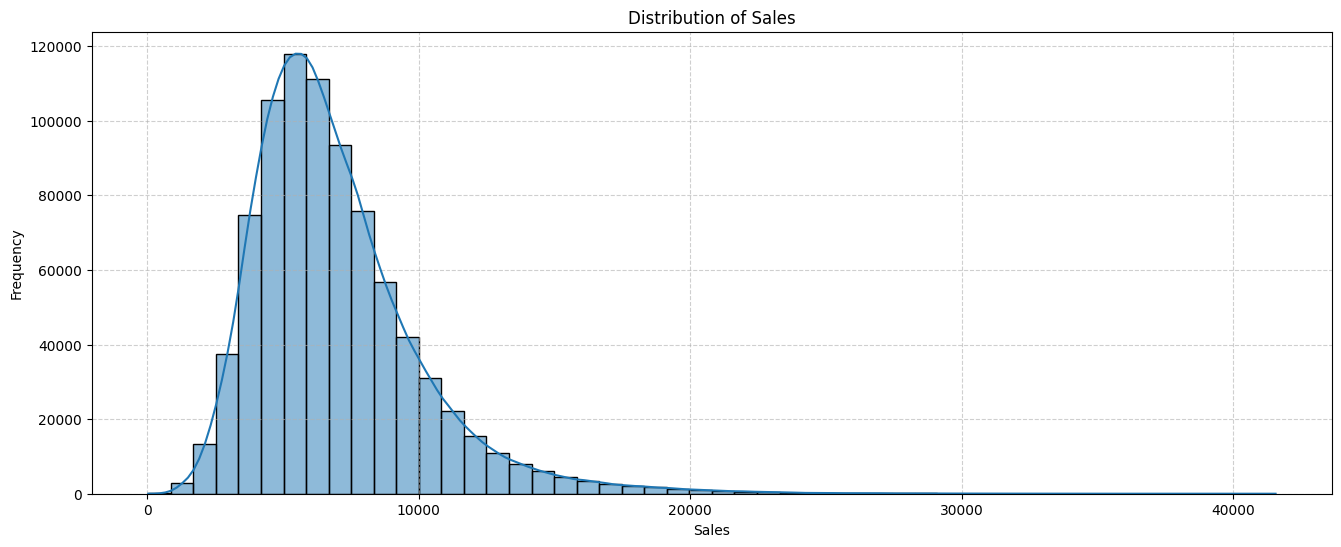

In [229]:
plt.figure(figsize=(16, 6))
sns.histplot(df['Sales'], bins = 50, kde = True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [230]:
print(f"Skewness of Sales: {df['Sales'].skew():.2f}")

Skewness of Sales: 1.59


In [231]:
# Variable exhibits a strong positive (right-sided) skewness with a skewness coefficient of 1.59. This indicates that the dataset is dominated by standard shopping days with moderate turnover, while featuring a long "right tail" that represents rare days with exceptionally high sales volume.
# Highly recommended to experiment with a log transformation of the target variable. 

In [232]:
# Basic statistics for Customers
print(round(df['Customers'].describe(),2))

count    844338.00
mean        762.78
std         401.19
min           8.00
25%         519.00
50%         676.00
75%         893.00
max        7388.00
Name: Customers, dtype: float64


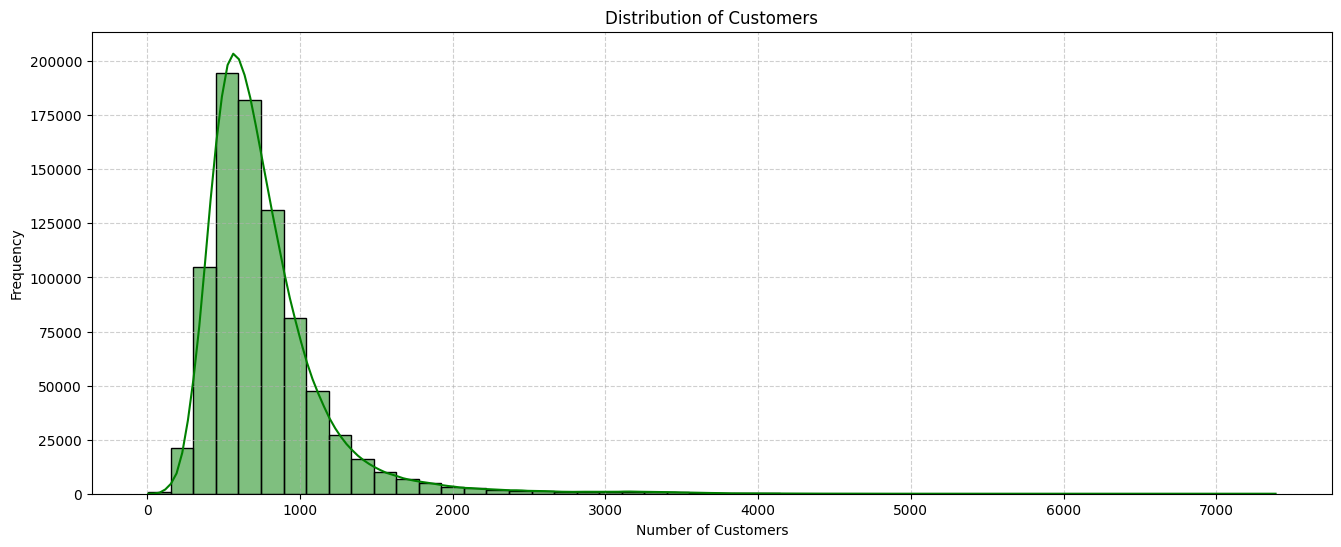

In [233]:
plt.figure(figsize=(16, 6))
sns.histplot(df['Customers'], bins=50, kde=True, color='green')
plt.title('Distribution of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [234]:
print(f"Skewness of Sales: {df['Customers'].skew():.2f}")

Skewness of Sales: 2.79


In [235]:
# The Customers variable exhibits positive (right-sided) skewness with a remarkably high skewness coefficient of 2.79. The vast majority of the data points are densely concentrated around low-to-moderate daily visitor counts, while the distribution features an exceptionally long and heavy right tail.

## Outlier Identification

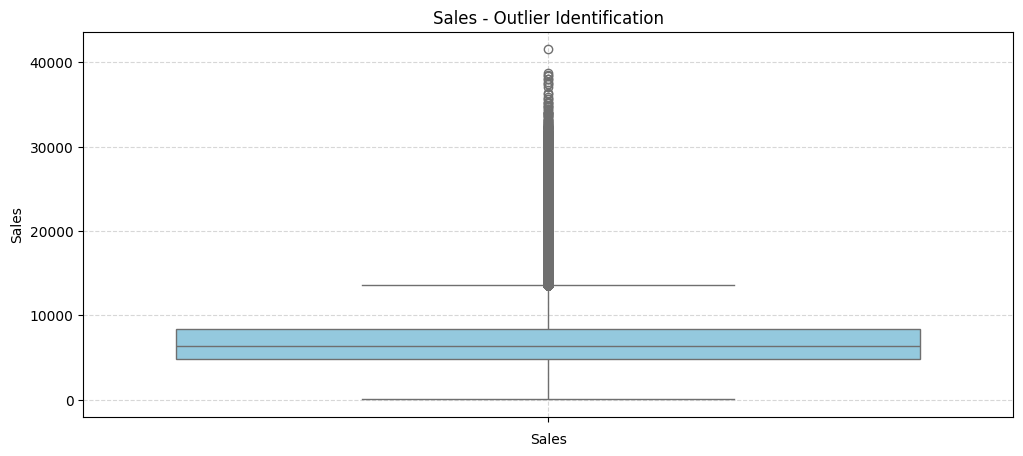

In [236]:
# for Sales
plt.figure(figsize=(12, 5))
sns.boxplot(y=df['Sales'], color='skyblue')
plt.title('Sales - Outlier Identification')
plt.xlabel('Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [237]:
Q1_sales = df['Sales'].quantile(0.25)
Q3_sales = df['Sales'].quantile(0.75)
print(f"Q1_sales:", Q1_sales)
print(f"Q3_sales:", Q3_sales)

Q1_sales: 4859.0
Q3_sales: 8360.0


In [238]:
IQR_cust = Q3_sales - Q1_sales
print(f"IQR_cust:", IQR_cust)

IQR_cust: 3501.0


In [239]:
IQR_sales = Q3_sales - Q1_sales
print(IQR_sales)

3501.0


In [240]:
upper_bound_sales = Q3_sales + 1.5 * IQR_sales
print(upper_bound_sales)
print(f"All data above {upper_bound_sales:.1f} will be categorized as outliers")

13611.5
All data above 13611.5 will be categorized as outliers


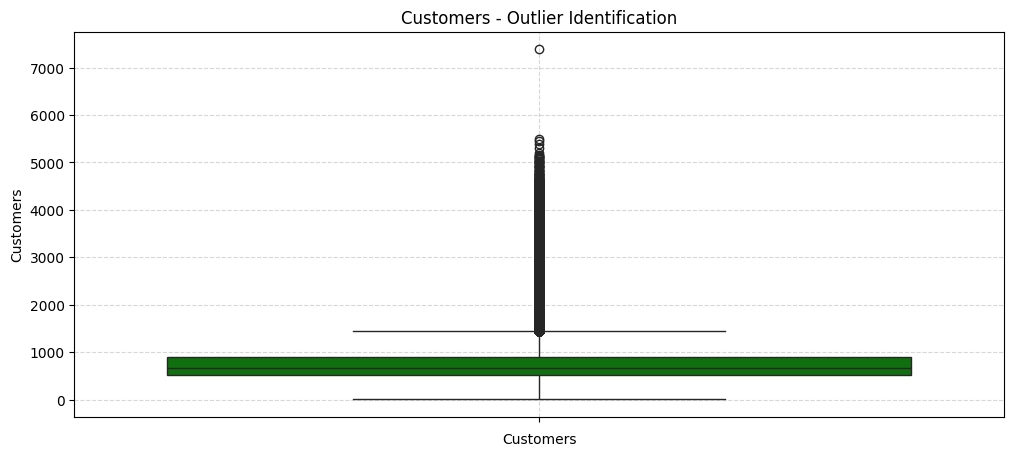

In [241]:
# for Customers
plt.figure(figsize=(12, 5))
sns.boxplot(y=df['Customers'], color='green')
plt.title('Customers - Outlier Identification')
plt.xlabel('Customers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [242]:
Q1_cust = df['Customers'].quantile(0.25)
Q3_cust = df['Customers'].quantile(0.75)
print(f"Q1_cust:", Q1_cust)
print(f"Q3_cust:", Q3_cust)

Q1_cust: 519.0
Q3_cust: 893.0


In [243]:
IQR_cust = Q3_cust - Q1_cust
print(f"IQR_cust:", IQR_cust)

IQR_cust: 374.0


In [244]:
upper_bound_cust = Q3_cust + 1.5 * IQR_cust
print(upper_bound_cust)
print(f"All data above {upper_bound_cust:.1f} will be categorized as outliers")

1454.0
All data above 1454.0 will be categorized as outliers


In [245]:
# Correlation between Sales & Cusotmers
correlation = df['Customers'].corr(df['Sales'])
print(round(correlation,2))

0.82


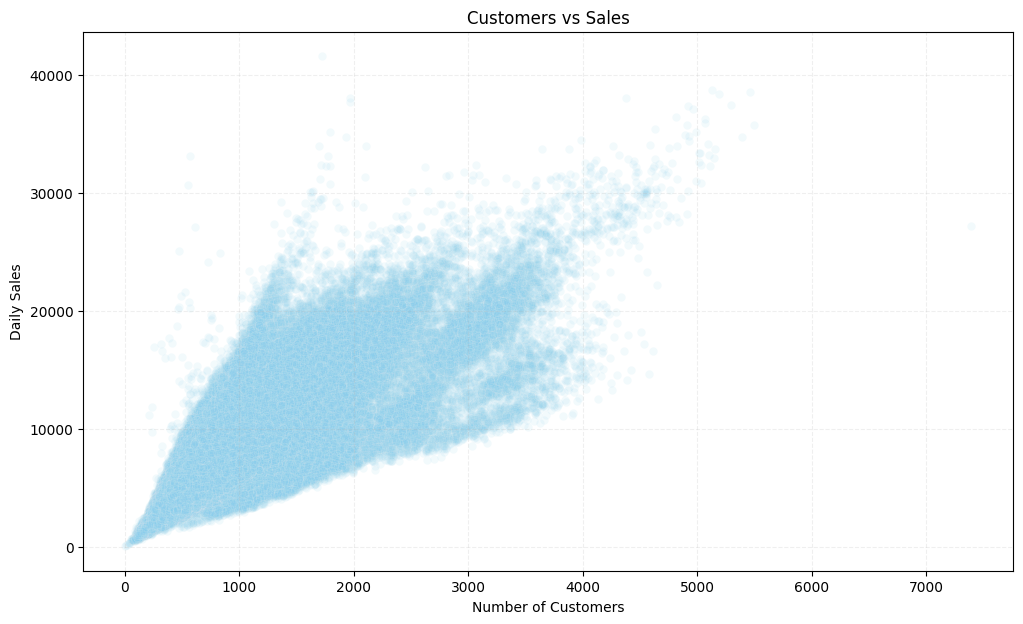

In [246]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Customers', y='Sales', alpha=0.1, color='skyblue')
plt.title(f'Customers vs Sales')
plt.xlabel('Number of Customers')
plt.ylabel('Daily Sales')
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

In [247]:
# Correlation coefficient of 0.82 confirms a positive linear relationship between daily foot traffic and revenue. Increase in customer volume is the primary driver of sales growth.

## Store Closure Analysis & Filtering

In [248]:
closed_stores = df[df['Open'] == 0]

print(f"Total number of records when stores are closed (Open == 0): {closed_stores.shape[0]}")
print(f"Sales during closures: Max = {closed_stores['Sales'].max()}, Min = {closed_stores['Sales'].min()}")
print(f"Customers during closures: Max = {closed_stores['Customers'].max()}, Min = {closed_stores['Customers'].min()}")

Total number of records when stores are closed (Open == 0): 0
Sales during closures: Max = nan, Min = nan
Customers during closures: Max = nan, Min = nan


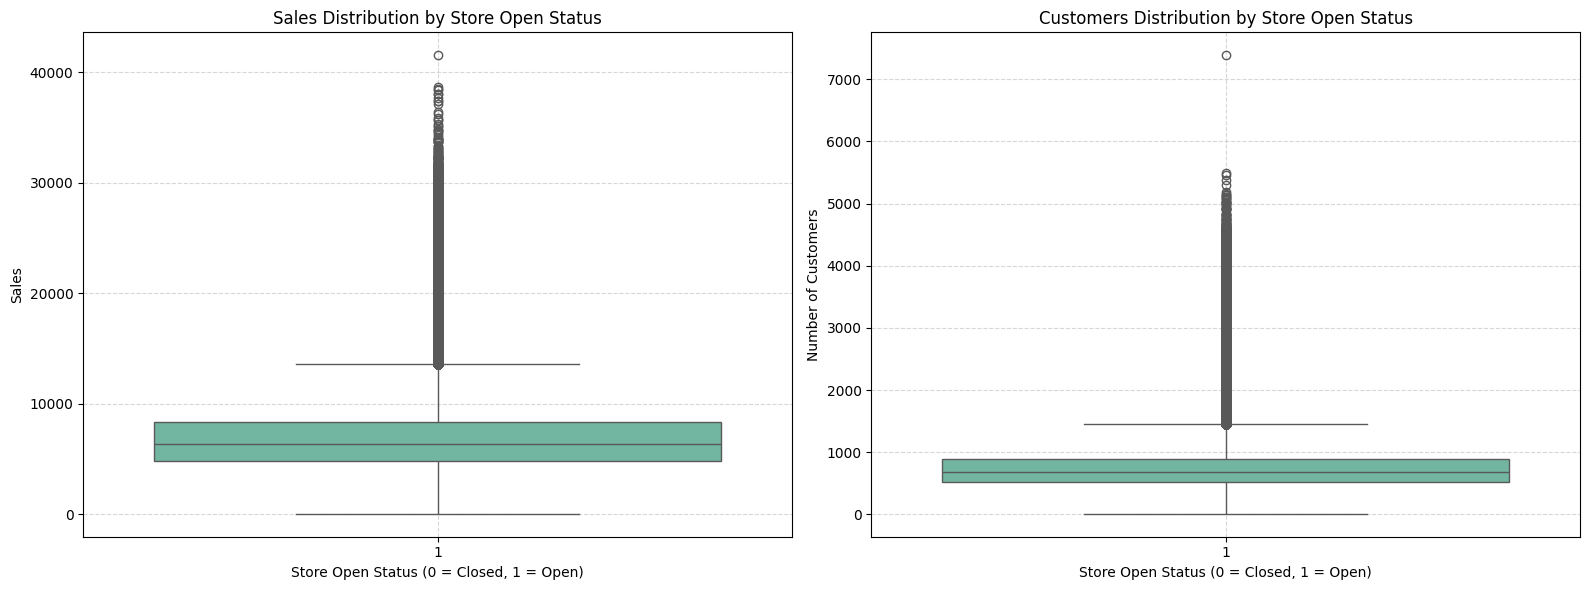

In [ ]:
#Sales by Open status
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Open', y='Sales', hue='Open', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Sales Distribution by Store Open Status')
axes[0].set_xlabel('Store Open Status (0 = Closed, 1 = Open)')
axes[0].set_ylabel('Sales')
axes[0].grid(True, linestyle='--', alpha=0.5)


#Customers by Open status
sns.boxplot(data=df, x='Open', y='Customers', ax=axes[1], hue='Open', palette='Set2', legend=False)
axes[1].set_title('Customers Distribution by Store Open Status')
axes[1].set_xlabel('Store Open Status (0 = Closed, 1 = Open)')
axes[1].set_ylabel('Number of Customers')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [251]:
df_train_ready = df[df['Open'] == 1]

print(f"Dataset shape before removing closed stores: {df.shape}")
print(f"Dataset shape after removing closed stores (Ready for Training): {df_train_ready.shape}")

Dataset shape before removing closed stores: (844338, 22)
Dataset shape after removing closed stores (Ready for Training): (844338, 22)
